In [25]:
import os
import pickle
import joblib
import math
import hdbscan
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import Birch, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch


In [26]:
graphs = pickle.load(open("graphs.pkl", "rb"))

In [27]:
graphs[0]

{'filename': '2612.png',
 'rooms': [{'type': 'common_room',
   'polygon': <POLYGON ((157 59, 157 109, 202 109, 202 59, 157 59))>,
   'area': 2250.0,
   'centroid': (179.5, 84.0)},
  {'type': 'master_room',
   'polygon': <POLYGON ((105 115, 105 124, 104 125, 76 125, 76 177, 120 177, 120 115, 105 ...>,
   'area': 2438.5,
   'centroid': (98.8933087280432, 149.0876905201285)},
  {'type': 'living_room',
   'polygon': <POLYGON ((105 59, 105 72, 104 73, 86 73, 86 89, 104 89, 105 90, 105 109, 12...>,
   'area': 6042.0,
   'centroid': (139.9478925300673, 118.26762661370407)},
  {'type': 'balcony',
   'polygon': <POLYGON ((126 183, 126 197, 179 197, 179 183, 126 183))>,
   'area': 742.0,
   'centroid': (152.5, 190.0)},
  {'type': 'bathroom',
   'polygon': <POLYGON ((54 59, 54 89, 80 89, 80 59, 54 59))>,
   'area': 780.0,
   'centroid': (67.0, 74.0)},
  {'type': 'kitchen',
   'polygon': <POLYGON ((54 95, 54 119, 99 119, 99 95, 54 95))>,
   'area': 1080.0,
   'centroid': (76.5, 107.0)}],
 'graph':

In [3]:
all_types = [
    'common_room', 
    'master_room', 
    'living_room',  
    'balcony',       
    'bathroom',      
    'kitchen',     
    'storage',      
    'dining',        
]



In [4]:

# Build a feature dictionary for each floorplan
feature_rows = []

for plan in graphs:
    feature_dict = {'filename': plan['filename']}
    
    # Group rooms by type
    rooms_by_type = {rtype: [] for rtype in all_types}
    for room in plan['rooms']:
        rooms_by_type[room['type']].append(room)
    
    # For each room type, take up to 3 rooms
    for room_type in all_types:
        selected_rooms = rooms_by_type[room_type][:3]
        # Fill in features for each of the up to 3 rooms
        for i in range(3):
            prefix = f"{room_type}_{i+1}"
            if i < len(selected_rooms):
                room = selected_rooms[i]
                feature_dict[f"{prefix}_x"] = room['centroid'][0]
                feature_dict[f"{prefix}_y"] = room['centroid'][1]
                feature_dict[f"{prefix}_area"] = room['area']
            else:
                # If room doesn't exist, fill with 0
                feature_dict[f"{prefix}_x"] = 0.0
                feature_dict[f"{prefix}_y"] = 0.0
                feature_dict[f"{prefix}_area"] = 0.0
    
    feature_rows.append(feature_dict)

# Create DataFrame
df = pd.DataFrame(feature_rows)

# Display the DataFrame to the user
df.set_index('filename', inplace=True)

df

,common_room_1_x,common_room_1_y,common_room_1_area,common_room_2_x,common_room_2_y,common_room_2_area,common_room_3_x,common_room_3_y,common_room_3_area,master_room_1_x,...,storage_3_area,dining_1_x,dining_1_y,dining_1_area,dining_2_x,dining_2_y,dining_2_area,dining_3_x,dining_3_y,dining_3_area
filename,,,,,,,,,,,,,,,,,,,,,
2612.png,179.500000,84.00000,2250.0,0.000000,0.000000,0.0,0.0,0.0,0.0,98.893309,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40808.png,174.500000,78.50000,1739.0,0.000000,0.000000,0.0,0.0,0.0,0.0,83.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36358.png,178.000000,100.00000,2352.0,0.000000,0.000000,0.0,0.0,0.0,0.0,103.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36392.png,88.500000,83.50000,1845.0,0.000000,0.000000,0.0,0.0,0.0,0.0,88.461523,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55553.png,153.035391,64.37161,1733.0,168.500000,110.000000,1160.0,0.0,0.0,0.0,160.500000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60974.png,99.500000,174.00000,2072.0,0.000000,0.000000,0.0,0.0,0.0,0.0,95.500000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60731.png,98.500000,92.00000,2150.0,0.000000,0.000000,0.0,0.0,0.0,0.0,101.211975,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41598.png,177.000000,94.00000,2400.0,0.000000,0.000000,0.0,0.0,0.0,0.0,99.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
coord_cols = [c for c in df.columns if c.endswith('_x') or c.endswith('_y')]
area_cols  = [c for c in df.columns if c.endswith('_area')]

# 2) Make a copy and normalize
df_norm = df.copy()
df_norm[coord_cols] = df_norm[coord_cols] / 256.0
df_norm[area_cols]  = df_norm[area_cols]  / (256.0 * 256.0)


df_norm = df_norm.loc[:, (df_norm != 0).any(axis=0)]

df_norm

,common_room_1_x,common_room_1_y,common_room_1_area,common_room_2_x,common_room_2_y,common_room_2_area,common_room_3_x,common_room_3_y,common_room_3_area,master_room_1_x,...,storage_2_area,storage_3_x,storage_3_y,storage_3_area,dining_1_x,dining_1_y,dining_1_area,dining_2_x,dining_2_y,dining_2_area
filename,,,,,,,,,,,,,,,,,,,,,
2612.png,0.701172,0.328125,0.034332,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.386302,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40808.png,0.681641,0.306641,0.026535,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.324219,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36358.png,0.695312,0.390625,0.035889,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.402344,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36392.png,0.345703,0.326172,0.028152,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.345553,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55553.png,0.597794,0.251452,0.026443,0.658203,0.429688,0.017700,0.0,0.0,0.0,0.626953,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60974.png,0.388672,0.679688,0.031616,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.373047,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60731.png,0.384766,0.359375,0.032806,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.395359,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41598.png,0.691406,0.367188,0.036621,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.386719,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_norm),
    index=df_norm.index,
    columns=df_norm.columns
)

X = df_scaled.values

In [7]:
num_data = 40000

In [ ]:

linked = sch.linkage(X[:num_data], method='ward')

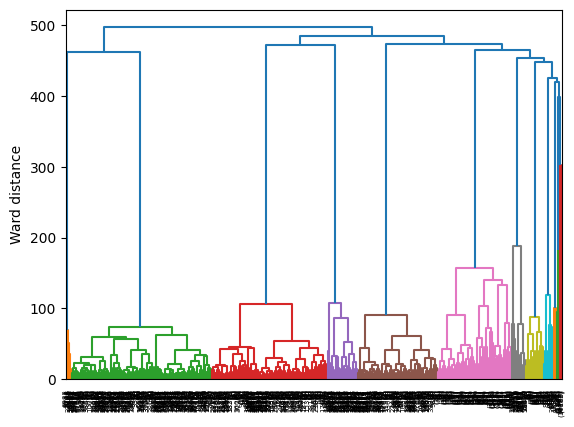

In [8]:
sch.dendrogram(linked, truncate_mode='level', p=10)
plt.ylabel("Ward distance")
plt.show()

In [8]:
clusterer = AgglomerativeClustering(n_clusters=20, linkage='ward')
labels = clusterer.fit_predict(X[:num_data])

In [9]:
# cnt = Counter(list(labels) + list(labels_rest))
cnt = Counter(list(labels))
for lbl, count in sorted(cnt.items()):
    if lbl == -1:
        print(f"  Noise points: {count}")
    else:
        print(f"  Cluster {lbl:>2}: {count} plans")

  Cluster  0: 9694 plans
  Cluster  1: 5637 plans
  Cluster  2: 4082 plans
  Cluster  3: 5037 plans
  Cluster  4: 1524 plans
  Cluster  5: 54 plans
  Cluster  6: 1961 plans
  Cluster  7: 2621 plans
  Cluster  8: 568 plans
  Cluster  9: 1128 plans
  Cluster 10: 60 plans
  Cluster 11: 4431 plans
  Cluster 12: 17 plans
  Cluster 13: 10 plans
  Cluster 14: 1302 plans
  Cluster 15: 8 plans
  Cluster 16: 321 plans
  Cluster 17: 475 plans
  Cluster 18: 620 plans
  Cluster 19: 450 plans


In [10]:
X[:num_data, :].shape

(40000, 63)

In [11]:
k_final = 20
num_data = 40000
cluster_centroids_16 = np.zeros((k_final, X.shape[1]), dtype=float)
X_first_n = X[:num_data]
for k in range(k_final):
    members = (labels == k)
    if np.any(members):
        cluster_centroids_16[k] = X_first_n[members].mean(axis=0)
    else:
        cluster_centroids_16[k] = 0.0

In [17]:
colnames = df_norm.columns

In [18]:
topn = 10
top_features_per_cluster = {}
for k in range(k_final):
    centroid_vals = cluster_centroids_16[k]
    top_indices = np.argsort(centroid_vals)[-topn:][::-1]
    top_features = [(colnames[idx], centroid_vals[idx]) for idx in top_indices]
    top_features_per_cluster[k] = top_features

    print(f"\nCluster {k} — top {topn} features (feature_name, z‐score):")
    for feat_name, zval in top_features:
        print(f"  {feat_name:30s}  {zval:6.2f}")


Cluster 0 — top 10 features (feature_name, z‐score):
  balcony_1_y                       0.50
  balcony_1_area                    0.39
  common_room_1_y                   0.38
  common_room_1_area                0.36
  balcony_1_x                       0.31
  kitchen_1_area                    0.19
  common_room_1_x                   0.15
  bathroom_1_area                   0.14
  master_room_1_area                0.13
  kitchen_1_y                       0.11

Cluster 1 — top 10 features (feature_name, z‐score):
  bathroom_2_y                      1.95
  bathroom_2_area                   1.86
  bathroom_2_x                      1.82
  common_room_2_area                1.03
  common_room_2_x                   0.96
  common_room_2_y                   0.94
  living_room_1_area                0.53
  balcony_1_y                       0.25
  master_room_1_y                   0.18
  master_room_1_area                0.17

Cluster 2 — top 10 features (feature_name, z‐score):
  kitchen_1_area  

In [19]:
N = 10
under_features_per_cluster = {}

for k in range(k_final):
    centroid_vals = cluster_centroids_16[k]

    neg_indices = np.argsort(centroid_vals)[:N]
    neg_feats = [(colnames[idx], centroid_vals[idx]) for idx in neg_indices]
    under_features_per_cluster[k] = neg_feats

    print(f"\nCluster {k} — top {N} under‐represented features (name, z‐score):")
    for feat_name, zval in neg_feats:
        print(f"  {feat_name:30s} {zval:6.2f}")


Cluster 0 — top 10 under‐represented features (name, z‐score):
  common_room_2_area              -0.90
  common_room_2_x                 -0.89
  common_room_2_y                 -0.88
  balcony_2_y                     -0.50
  balcony_2_x                     -0.49
  bathroom_2_y                    -0.47
  balcony_2_area                  -0.45
  bathroom_2_area                 -0.45
  bathroom_2_x                    -0.44
  living_room_1_area              -0.28

Cluster 1 — top 10 under‐represented features (name, z‐score):
  balcony_2_y                     -0.53
  balcony_2_x                     -0.51
  balcony_2_area                  -0.47
  bathroom_1_y                    -0.46
  common_room_1_y                 -0.30
  bathroom_1_area                 -0.22
  storage_1_y                     -0.19
  storage_1_x                     -0.19
  storage_1_area                  -0.16
  dining_1_x                      -0.12

Cluster 2 — top 10 under‐represented features (name, z‐score):
  balcon

In [20]:
filenames = df.index

In [21]:
cosim_matrix = cosine_similarity(X, cluster_centroids_16) 
cosim_matrix.shape

cosim_colnames = [f"cos_sim_{k}" for k in range(k_final)]
df_cosim = pd.DataFrame(cosim_matrix, index=filenames, columns=cosim_colnames)

df_features = pd.DataFrame(X, index=filenames, columns=colnames)

In [22]:
df_result = pd.concat([df_cosim, df_features, ], axis=1)[:num_data]
df_result['cluster'] = labels

In [23]:
df_result = df_result[[df_result.columns[-1]] + list(df_result.columns[:-1])]

In [24]:
df_result.to_csv("raw_feat_cluster_results_numerical.csv")